In [9]:
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
from envs.env_helper import *
import argparse
import os
from main import ENV_CONFIG
import torch
from agent.rfsac.rfsac_agent import RFVCritic, nystromVCritic
from agent.rfsac import rfsac_agent
from agent.sac import sac_agent
from agent.sac.actor import DiagGaussianActor
from utils.util import eval_policy, get_traj
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [26]:
def eval_with_traj(log_path, ):
    with open(os.path.join(log_path, 'train_params.pkl'), 'rb') as f:        
        kwargs = pkl.load(f)
    env_name = kwargs['env']
    
    eval_config = ENV_CONFIG.copy()
    eval_config.update({'reward_scale': 1.0,
                        'eval': True,
                        'reward_exponential': False,
                        'reward_type': 'energy',
                        'noise_scale': kwargs['sigma']})
    
    if env_name == "Pendulum-v1":
        eval_env = env_creator_pendulum(eval_config)
    elif env_name == 'Quadrotor2D-v2':
        eval_env = env_creator_quad2d(eval_config)
    elif env_name == 'Pendubot-v0':
        eval_env = env_creator_pendubot(eval_config)
    elif env_name == 'CartPoleContinuous-v0':
        eval_env = env_creator_cartpole(eval_config)
    elif env_name == 'CartPendulum-v0':
        eval_env = env_creator_cartpendulum(eval_config)
    eval_env = Gymnasium2GymWrapper(eval_env)
    kwargs['action_space'] = eval_env.action_space
    kwargs.update({'eval': True})
    if kwargs['alg'] == "sac":
        agent = sac_agent.SACAgent(**kwargs)
    elif kwargs['alg'] == 'rfsac':
        agent = rfsac_agent.RFSACAgent(**kwargs)

    use_nystrom = kwargs['use_nystrom']

    actor = DiagGaussianActor(obs_dim=kwargs['obs_space_dim'][0],
                              action_dim=kwargs['action_dim'],
                              hidden_dim=kwargs['hidden_dim'],
                              hidden_depth=2,
                              log_std_bounds=[-5., 2.])
    # if use_nystrom == False:
    #     critic = RFVCritic(**kwargs)
    # else:
    #     critic = nystromVCritic(**kwargs)
    try:
        actor.load_state_dict(torch.load(log_path+"/best_actor.pth", map_location={'cuda': 'cpu',
                                                                                   'cuda:0': 'cpu',
                                                                                   'cuda:1': 'cpu'}))
    except:
        actor.load_state_dict(torch.load(log_path+"/actor.pth", map_location={'cuda': 'cpu',
                                                                                   'cuda:0': 'cpu',
                                                                                   'cuda:1': 'cpu'}))
    # critic.load_state_dict(torch.load(log_path + "/critic.pth"))
    agent.actor = actor
    agent.device = torch.device("cpu")
    # agent.critic = critic

    traj = get_traj(agent, eval_env, seed=0)

    return traj

In [71]:
sac_trajs = [eval_with_traj('/home/haitong/PycharmProjects/lvrep-rl-cloned/log/Quadrotor2D-v2_sigma_1.0_rew_scale_10.0/sac/seed_1_2024-11-28-20-09-20')
             for i in range(5)]

---------------------------------------
Evaluation : avg eplen 180.0, return-50.364
---------------------------------------
---------------------------------------
Evaluation : avg eplen 180.0, return-28.823
---------------------------------------
---------------------------------------
Evaluation : avg eplen 180.0, return-82.384
---------------------------------------
---------------------------------------
Evaluation : avg eplen 180.0, return-93.295
---------------------------------------
---------------------------------------
Evaluation : avg eplen 180.0, return-90.322
---------------------------------------


In [75]:
rf_trajs = [eval_with_traj('/home/haitong/PycharmProjects/lvrep-rl-cloned/log/Quadrotor2D-v2_sigma_1.0_rew_scale_10.0/rfsac_nystrom_False_rf_num_2048_learn_rf_True/seed_1_2023-09-10-18-42-10') for i in range(5)]

critic alpha: 0.0
---------------------------------------
Evaluation : avg eplen 180.0, return-8.402
---------------------------------------
critic alpha: 0.0
---------------------------------------
Evaluation : avg eplen 180.0, return-3.331
---------------------------------------
critic alpha: 0.0
---------------------------------------
Evaluation : avg eplen 180.0, return-2.564
---------------------------------------
critic alpha: 0.0
---------------------------------------
Evaluation : avg eplen 180.0, return-4.945
---------------------------------------
critic alpha: 0.0
---------------------------------------
Evaluation : avg eplen 180.0, return-5.165
---------------------------------------


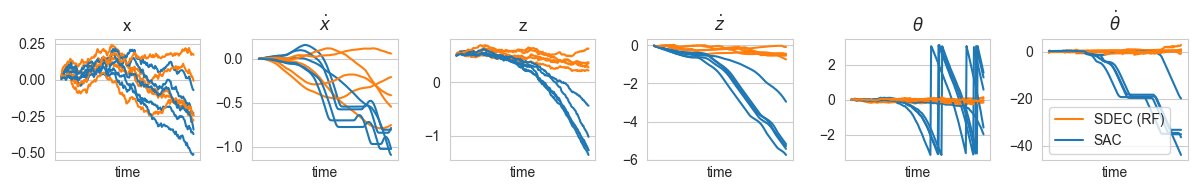

In [84]:
import seaborn as sns
sns.set_style('whitegrid')
fig, axs = plt.subplots(1, 6, figsize = (12, 2))
titles = [r'x', r'$\dot x$', r'z', r'$\dot z$', r'$\theta$', r'$\dot \theta$']
for j in range(5):
    for i in range(6):
        if i == 4:
            axs[i].plot(np.arctan2(sac_trajs[j][:, 5], sac_trajs[j][:, 4]), label='SAC', color='tab:blue')
            axs[i].plot(np.arctan2(rf_trajs[j][:, 5], rf_trajs[j][:, 4]), label='SDEC (RF)', color='tab:orange')
        elif i == 5:
            axs[i].plot(rf_trajs[j][:, 6], label='SDEC (RF)', color='tab:orange')
            axs[i].plot(sac_trajs[j][:, 6], label='SAC', color='tab:blue')
        else:
            axs[i].plot(rf_trajs[j][:, i], label='SDEC (RF)', color='tab:orange')
            axs[i].plot(sac_trajs[j][:, i], label='SAC', color='tab:blue')
        axs[i].set_title(titles[i])
        axs[i].set_xticks([])
        axs[i].set_xlabel('time')
axs[-1].legend()
h, l = axs[-1].get_legend_handles_labels()
axs[-1].get_legend().remove()
axs[-1].legend(h[:2], l[:2])
plt.tight_layout()
plt.savefig('/home/haitong/PycharmProjects/lvrep-rl-cloned/utils/microscopic.pdf')

In [69]:
sac_traj

array([[ 1.37290827e-02,  2.31913333e-05,  4.97372910e-01, ...,
         9.99838357e-01,  1.79794380e-02,  3.06179233e-01],
       [ 2.21118860e-02,  7.94526713e-04,  5.06679876e-01, ...,
         9.99900719e-01,  1.40908775e-02,  2.87408311e-01],
       [ 3.07471577e-02,  1.40711401e-03,  4.92587171e-01, ...,
         9.99965435e-01,  8.31441975e-03,  2.83274125e-01],
       ...,
       [-2.44477741e-01, -9.41938114e-01, -8.22222261e-01, ...,
        -8.07240137e-01,  5.90223145e-01, -3.45488676e+01],
       [-2.60669754e-01, -9.41936802e-01, -8.54499140e-01, ...,
        -6.88232659e-01,  7.25490047e-01, -3.45489133e+01],
       [-2.56213307e-01, -9.41934976e-01, -8.89083745e-01, ...,
        -5.44122476e-01,  8.39005799e-01, -3.45489677e+01]])